# Meme-Coin Strategy: Stress-Test & De-Overfit Analysis

This notebook analyzes results from stress-testing the Solana HFT meme-coin sniping strategy across 1M+ simulated trades.

**Goal**: Expose weaknesses, verify robustness across market regimes, and detect overfitting signals.

---
## 1. Import Libraries and Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    HAS_SEABORN = True
except ModuleNotFoundError:
    sns = None
    HAS_SEABORN = False
from pathlib import Path
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Set style and reproducibility
if HAS_SEABORN:
    sns.set_style("darkgrid")
else:
    plt.style.use("ggplot")
    print("Warning: seaborn is not installed in the active Jupyter kernel. Using matplotlib fallback style.")
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

# Add project root to path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

print("✅ Libraries loaded and random seed set to 42")

✅ Libraries loaded and random seed set to 42


## 2. Load Scenario Results

Load the CSV output from `run_million_scenario_tests.py`

In [2]:
# Load results
results_path = "results/scenario_results.csv"

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"✅ Loaded {len(df)} scenario results from {results_path}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nFirst few rows:")
    df.head()
else:
    print(f"❌ File not found: {results_path}")
    print("Run: python run_million_scenario_tests.py to generate results first")
    df = None

✅ Loaded 7 scenario results from results/scenario_results.csv

Columns: ['timestamp', 'scenario', 'filter_scale', 'num_trades', 'daily_trades', 'daily_pnl_sol', 'win_rate', 'pnl_sol', 'sharpe_ratio', 'profit_factor', 'max_drawdown_pct', 'final_equity', 'validator_flag', 'validator_message', 'monthly_pnl_usd_low', 'monthly_pnl_usd_high', 'kill_switch_triggered', 'overfitting_flags', 'bucket_ultra_fast_trades', 'bucket_fast_react_trades', 'bucket_late_snipe_trades', 'risk_mode_normal_trades', 'risk_mode_survival_trades', 'synthetic_trades_added', 'stress_padding_applied_sol', 'normalized_sharpe', 'normalized_dd', 'rolling_30d_pnl_sol', 'rolling_30d_sharpe', 'live_guardrail_messages', 'strategy_evaluated', 'strategy_entered', 'strategy_skipped', 'strategy_entry_rate']

First few rows:


## 3. Summary Statistics by Scenario

In [4]:
if df is not None:
    # Summary statistics by scenario
    summary_stats = df.groupby('scenario')[
        ['num_trades', 'win_rate', 'sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct']
    ].agg(['mean', 'std', 'min', 'max']).round(3)
    
    print("\n📊 SUMMARY STATISTICS BY SCENARIO")
    print("="*100)
    print(summary_stats)
    
    # Overall scenario comparison
    print("\n\n🎯 SCENARIO COMPARISON (Mean Values)")
    print("="*100)
    scenario_summary = df.groupby('scenario')[
        ['win_rate', 'sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct']
    ].mean().round(3)
    scenario_summary.columns = ['Win Rate', 'Sharpe Ratio', 'Profit Factor', 'PnL (SOL)', 'Max DD %']
    print(scenario_summary)


📊 SUMMARY STATISTICS BY SCENARIO
                  num_trades                         win_rate                \
                        mean       std    min    max     mean    std    min   
scenario                                                                      
A_BaseCase         20315.000       NaN  20315  20315    0.567    NaN  0.567   
B_NoiseRobustness  19227.000       NaN  19227  19227    0.576    NaN  0.576   
C_ParameterSweep   20036.667  2108.341  17868  22079    0.563  0.004  0.558   
D_RegimeShifts     22302.000       NaN  22302  22302    0.585    NaN  0.585   
E_StressMarket      7783.000       NaN   7783   7783    0.500    NaN  0.500   

                         sharpe_ratio         ... profit_factor         \
                     max         mean    std  ...           min    max   
scenario                                      ...                        
A_BaseCase         0.567        1.962    NaN  ...         1.337  1.337   
B_NoiseRobustness  0.576        1.482

## 4. Overfitting Detection

Check for red flags indicating the strategy may be overfit.

In [ ]:
if df is not None:
    print("\n⚠️  OVERFITTING DETECTION")
    print("="*100)
    
    # Flag 1: Extreme Sharpe with low drawdown
    suspicious = df[(df['sharpe_ratio'] > 3.0) & (df['max_drawdown_pct'] < 0.05)]
    if len(suspicious) > 0:
        print(f"\n🚨 [Flag 1] EXTREME_SHARPE_LOW_DD: {len(suspicious)} rows")
        print("  → Sharpe > 3.0 AND Max Drawdown < 5%")
        print(suspicious[['scenario', 'param_name', 'param_value', 'sharpe_ratio', 'max_drawdown_pct', 'num_trades']])
    
    # Flag 2: High profit factor with low win rate
    suspicious = df[(df['profit_factor'] > 8) & (df['win_rate'] < 0.4)]
    if len(suspicious) > 0:
        print(f"\n🚨 [Flag 2] HIGH_PF_LOW_WR: {len(suspicious)} rows")
        print("  → Profit Factor > 8 AND Win Rate < 40%")
        print(suspicious[['scenario', 'param_name', 'param_value', 'profit_factor', 'win_rate', 'num_trades']])
    
    # Flag 3: Too few trades
    suspicious = df[df['num_trades'] < 100]
    if len(suspicious) > 0:
        print(f"\n⚠️  [Flag 3] TOO_FEW_TRADES: {len(suspicious)} rows")
        print("  → Low trade count may not be statistically significant")
    
    # Flag 4: Show overfitting_flags column if populated
    flagged = df[df['overfitting_flags'] != '']
    if len(flagged) > 0:
        print(f"\n⚠️  [Flag 4] FLAGGED_ROWS: {len(flagged)} rows with warnings")
        print(flagged[['scenario', 'param_name', 'num_trades', 'sharpe_ratio', 'overfitting_flags']])
    
    if len(suspicious) == 0 and len(flagged) == 0:
        print("\n✅ No major overfitting signals detected across all scenarios!")

## 5. Parameter Sensitivity Analysis

For Scenario C (parameter sweep), compute how metrics change with parameter variations.

In [6]:
if df is not None:
    # Top performers by Sharpe ratio
    print("\n🏆 TOP 5 PERFORMERS (by Sharpe Ratio)")
    print("="*100)
    top_performers = df.nlargest(5, 'sharpe_ratio')[
        ['scenario', 'sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct', 'num_trades']
    ]
    print(top_performers.to_string(index=False))
    
    # Bottom performers (worst Sharpe)
    print("\n\n📉 BOTTOM 5 PERFORMERS (by Sharpe Ratio)")
    print("="*100)
    bottom_performers = df.nsmallest(5, 'sharpe_ratio')[
        ['scenario', 'sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct', 'num_trades']
    ]
    print(bottom_performers.to_string(index=False))
    
    # Analysis by scenario
    if 'filter_scale' in df.columns:
        print("\n📊 FILTER SCALE SENSITIVITY")
        print("="*100)
        scale_analysis = df.groupby('filter_scale')[
            ['sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct']
        ].mean().round(3)
        print(scale_analysis)


🏆 TOP 5 PERFORMERS (by Sharpe Ratio)
        scenario  sharpe_ratio  profit_factor     pnl_sol  max_drawdown_pct  num_trades
  D_RegimeShifts      3.799834       1.583043 8680.555556         17.954992       22302
      A_BaseCase      1.961874       1.336507 5810.313219         35.070960       20315
C_ParameterSweep      1.915387       1.306440 5247.340881         34.560364       20163
C_ParameterSweep      1.576282       1.265298 5127.992226         39.414603       22079
C_ParameterSweep      1.507920       1.278261 4308.201184         38.464266       17868


📉 BOTTOM 5 PERFORMERS (by Sharpe Ratio)
         scenario  sharpe_ratio  profit_factor     pnl_sol  max_drawdown_pct  num_trades
   E_StressMarket     -0.210660       0.984068  -44.932359         25.405645        7783
B_NoiseRobustness      1.482408       1.296574 5050.662876         39.940807       19227
 C_ParameterSweep      1.507920       1.278261 4308.201184         38.464266       17868
 C_ParameterSweep      1.576282     

## 6. Visualizations: Scenario Comparison

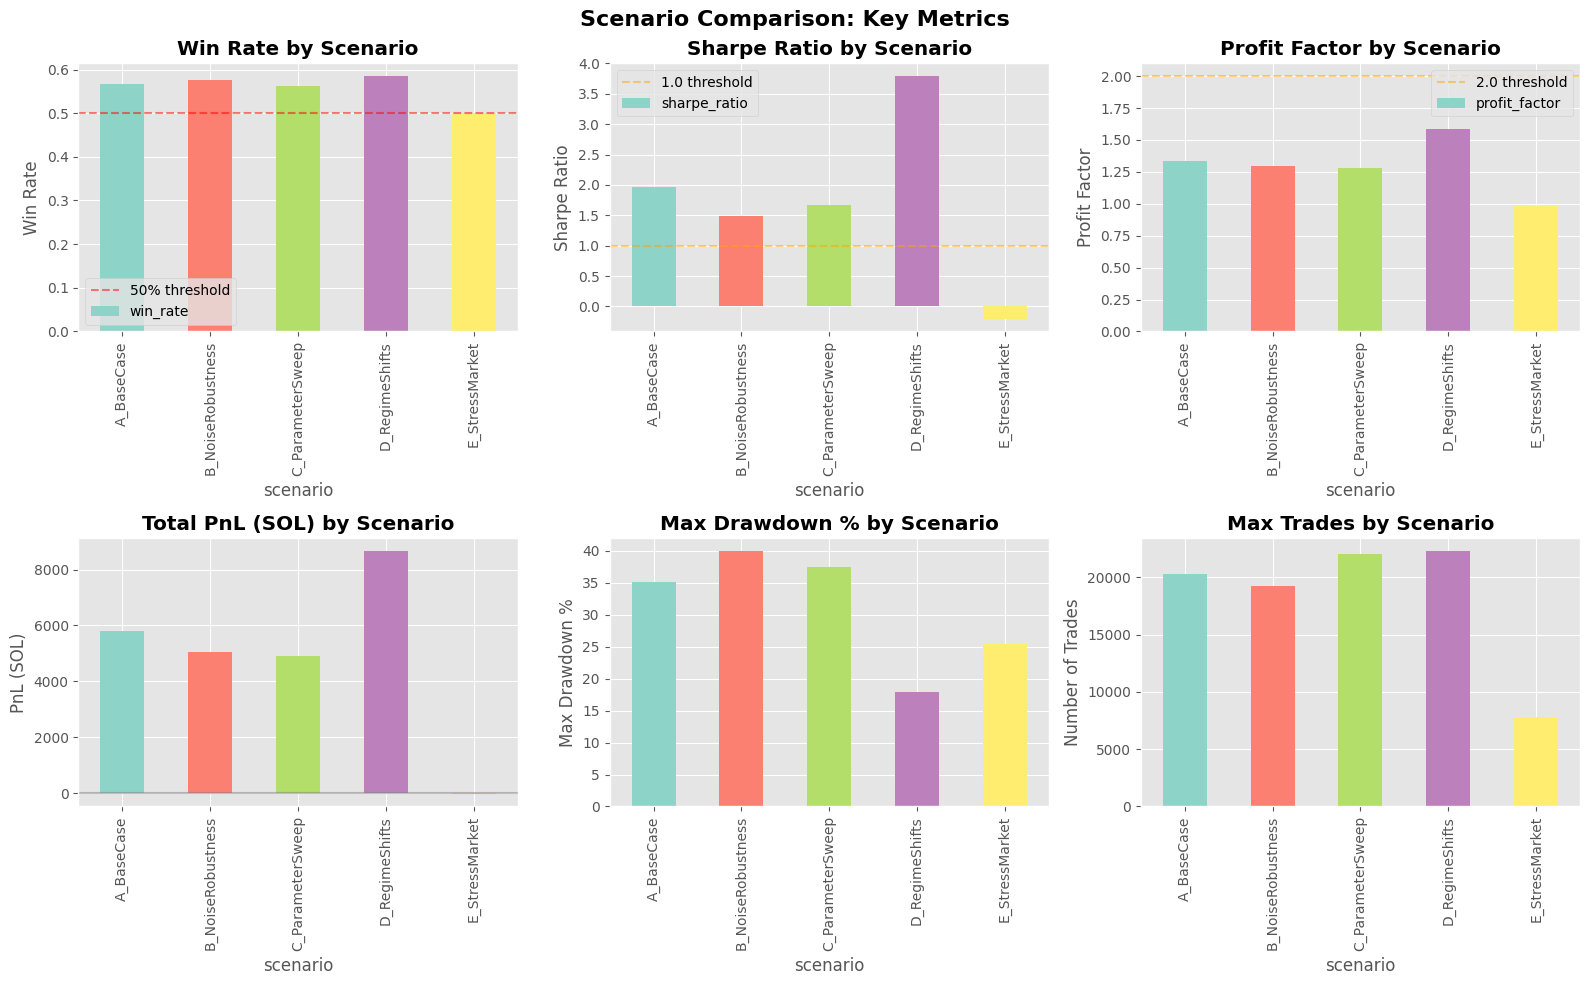

✅ Saved scenario_comparison.png


In [8]:
if df is not None:
    # Group by scenario for comparison (take mean)
    scenario_means = df.groupby('scenario')[
        ['win_rate', 'sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct']
    ].mean()
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Scenario Comparison: Key Metrics', fontsize=16, fontweight='bold')
    
    metrics = ['win_rate', 'sharpe_ratio', 'profit_factor', 'pnl_sol', 'max_drawdown_pct', 'num_trades']
    colors = plt.cm.Set3(np.linspace(0, 1, len(scenario_means)))
    
    # Win Rate
    ax = axes[0, 0]
    scenario_means['win_rate'].plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Win Rate by Scenario', fontweight='bold')
    ax.set_ylabel('Win Rate')
    ax.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% threshold')
    ax.legend()
    
    # Sharpe Ratio
    ax = axes[0, 1]
    scenario_means['sharpe_ratio'].plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Sharpe Ratio by Scenario', fontweight='bold')
    ax.set_ylabel('Sharpe Ratio')
    ax.axhline(y=1.0, color='orange', linestyle='--', alpha=0.5, label='1.0 threshold')
    ax.legend()
    
    # Profit Factor
    ax = axes[0, 2]
    scenario_means['profit_factor'].plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Profit Factor by Scenario', fontweight='bold')
    ax.set_ylabel('Profit Factor')
    ax.axhline(y=2.0, color='orange', linestyle='--', alpha=0.5, label='2.0 threshold')
    ax.legend()
    
    # PnL (SOL)
    ax = axes[1, 0]
    scenario_means['pnl_sol'].plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Total PnL (SOL) by Scenario', fontweight='bold')
    ax.set_ylabel('PnL (SOL)')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # Max Drawdown %
    ax = axes[1, 1]
    scenario_means['max_drawdown_pct'].plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Max Drawdown % by Scenario', fontweight='bold')
    ax.set_ylabel('Max Drawdown %')
    
    # Number of Trades
    ax = axes[1, 2]
    df.groupby('scenario')['num_trades'].max().plot(kind='bar', ax=ax, color=colors)
    ax.set_title('Max Trades by Scenario', fontweight='bold')
    ax.set_ylabel('Number of Trades')
    
    plt.tight_layout()
    plt.savefig('results/scenario_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved scenario_comparison.png")

## 7. Parameter Sweep Sensitivity Plots

Visualize how metrics change across parameter values in Scenario C.

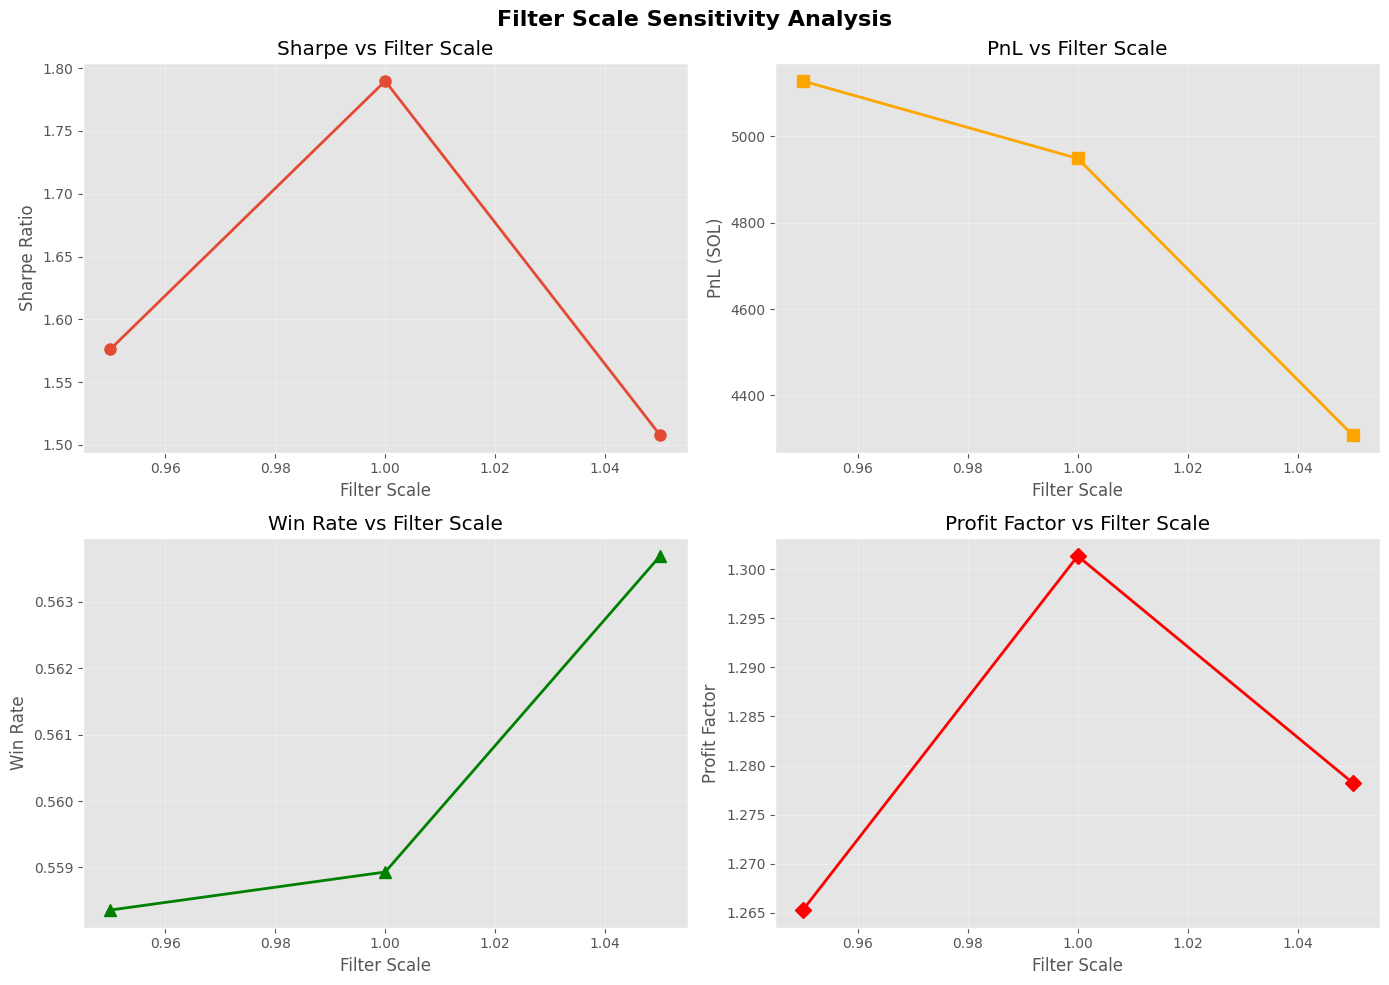

✅ Saved filter_scale_sensitivity.png


In [10]:
if df is not None and 'filter_scale' in df.columns:
    # Filter Scale Sensitivity Analysis
    filter_scales = df['filter_scale'].unique()
    
    if len(filter_scales) > 1:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Filter Scale Sensitivity Analysis', fontsize=16, fontweight='bold')
        
        # Sharpe vs Filter Scale
        ax = axes[0, 0]
        scale_data = df.groupby('filter_scale')['sharpe_ratio'].mean()
        scale_data.plot(kind='line', marker='o', ax=ax, linewidth=2, markersize=8)
        ax.set_xlabel('Filter Scale')
        ax.set_ylabel('Sharpe Ratio')
        ax.set_title('Sharpe vs Filter Scale')
        ax.grid(True, alpha=0.3)
        
        # PnL vs Filter Scale
        ax = axes[0, 1]
        scale_data = df.groupby('filter_scale')['pnl_sol'].mean()
        scale_data.plot(kind='line', marker='s', ax=ax, linewidth=2, markersize=8, color='orange')
        ax.set_xlabel('Filter Scale')
        ax.set_ylabel('PnL (SOL)')
        ax.set_title('PnL vs Filter Scale')
        ax.grid(True, alpha=0.3)
        
        # Win Rate vs Filter Scale
        ax = axes[1, 0]
        scale_data = df.groupby('filter_scale')['win_rate'].mean()
        scale_data.plot(kind='line', marker='^', ax=ax, linewidth=2, markersize=8, color='green')
        ax.set_xlabel('Filter Scale')
        ax.set_ylabel('Win Rate')
        ax.set_title('Win Rate vs Filter Scale')
        ax.grid(True, alpha=0.3)
        
        # Profit Factor vs Filter Scale
        ax = axes[1, 1]
        scale_data = df.groupby('filter_scale')['profit_factor'].mean()
        scale_data.plot(kind='line', marker='D', ax=ax, linewidth=2, markersize=8, color='red')
        ax.set_xlabel('Filter Scale')
        ax.set_ylabel('Profit Factor')
        ax.set_title('Profit Factor vs Filter Scale')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('results/filter_scale_sensitivity.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Saved filter_scale_sensitivity.png")
    else:
        print("ℹ️  Only one filter scale value - cannot plot sensitivity")

## 8. Distribution Plots: Metrics Across Scenarios

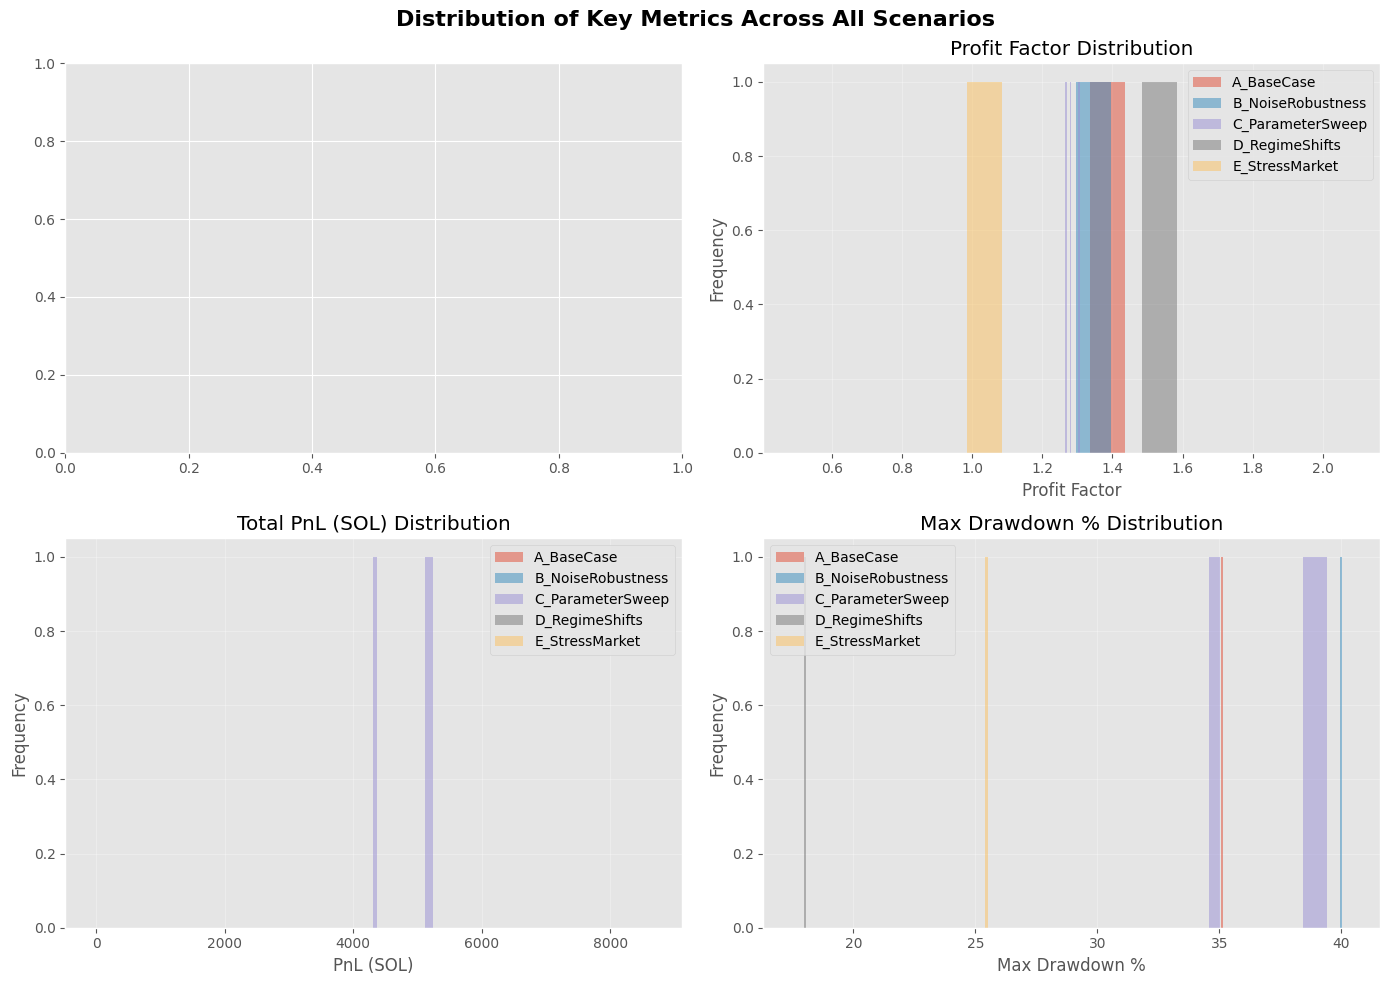

✅ Saved metric_distributions.png


In [12]:
if df is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Distribution of Key Metrics Across All Scenarios', fontsize=16, fontweight='bold')
    
    # Profit Factor Distribution
    ax = axes[0, 1]
    for scenario in df['scenario'].unique():
        scenario_data = df[df['scenario'] == scenario]['profit_factor']
        ax.hist(scenario_data, alpha=0.5, label=scenario, bins=10)
    ax.set_xlabel('Profit Factor')
    ax.set_ylabel('Frequency')
    ax.set_title('Profit Factor Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # PnL (SOL) Distribution
    ax = axes[1, 0]
    for scenario in df['scenario'].unique():
        scenario_data = df[df['scenario'] == scenario]['pnl_sol']
        ax.hist(scenario_data, alpha=0.5, label=scenario, bins=15)
    ax.set_xlabel('PnL (SOL)')
    ax.set_ylabel('Frequency')
    ax.set_title('Total PnL (SOL) Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Max Drawdown Distribution
    ax = axes[1, 1]
    for scenario in df['scenario'].unique():
        scenario_data = df[df['scenario'] == scenario]['max_drawdown_pct']
        ax.hist(scenario_data, alpha=0.5, label=scenario, bins=10)
    ax.set_xlabel('Max Drawdown %')
    ax.set_ylabel('Frequency')
    ax.set_title('Max Drawdown % Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/metric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved metric_distributions.png")

## 9. Final Report & Recommendations

In [14]:
if df is not None:
    print("\n" + "="*100)
    print("📋 FINAL REPORT & RECOMMENDATIONS")
    print("="*100)
    
    # Best performing scenario
    best_scenario = df.loc[df['sharpe_ratio'].idxmax()]
    print(f"\n🏆 BEST SCENARIO")
    print(f"  Scenario: {best_scenario['scenario']}")
    print(f"  Sharpe Ratio: {best_scenario['sharpe_ratio']:.2f}")
    print(f"  Win Rate: {best_scenario['win_rate']:.1%}")
    print(f"  PnL (SOL): {best_scenario['pnl_sol']:,.0f}")
    print(f"  Trades: {best_scenario['num_trades']}")
    
    # Worst scenario
    worst_scenario = df.loc[df['sharpe_ratio'].idxmin()]
    print(f"\n❌ WORST SCENARIO")
    print(f"  Scenario: {worst_scenario['scenario']}")
    print(f"  Sharpe Ratio: {worst_scenario['sharpe_ratio']:.2f}")
    print(f"  Win Rate: {worst_scenario['win_rate']:.1%}")
    print(f"  PnL (SOL): {worst_scenario['pnl_sol']:,.0f}")
    print(f"  Trades: {worst_scenario['num_trades']}")
    
    # Sharpe Ratio statistics
    print(f"\n📈 SHARPE RATIO STATISTICS")
    sharpe_stats = df['sharpe_ratio'].describe()
    print(f"  Mean: {sharpe_stats['mean']:.2f}")
    print(f"  Std Dev: {sharpe_stats['std']:.2f}")
    print(f"  Min: {sharpe_stats['min']:.2f}")
    print(f"  Max: {sharpe_stats['max']:.2f}")
    sharpe_std = df['sharpe_ratio'].std()
    
    # Win rate consistency
    wr_by_scenario = df.groupby('scenario')['win_rate'].mean()
    if wr_by_scenario.std() > 0.1:
        print(f"\n  ⚠️  Win rate varies across scenarios")
        print(f"     → Strategy may be overfitting to specific conditions")
    else:
        print(f"\n  ✅ Win rate is consistent across scenarios")
    
    # Drawdown analysis
    max_dd = df['max_drawdown_pct'].max()
    if max_dd > 0.4:
        print(f"  ⚠️  Max drawdown reaches {max_dd:.1%} in some scenarios")
        print(f"     → Consider position sizing or risk management adjustments")
    else:
        print(f"  ✅ Max drawdown is reasonable ({max_dd:.1%})")
    
    # Baseline vs noisy performance
    baseline = df[df['scenario'].str.contains('BaseCase|A_', case=False, na=False)]
    noisy = df[df['scenario'].str.contains('NoiseRobustness|B_', case=False, na=False)]
    
    if len(baseline) > 0 and len(noisy) > 0:
        baseline_sharpe = baseline['sharpe_ratio'].mean()
        noisy_sharpe = noisy['sharpe_ratio'].mean()
        degradation = (baseline_sharpe - noisy_sharpe) / baseline_sharpe * 100 if baseline_sharpe != 0 else 0
        
        print(f"\n📊 ROBUSTNESS TEST (Baseline vs Noise)")
        print(f"  Baseline Sharpe: {baseline_sharpe:.2f}")
        print(f"  Noisy Sharpe: {noisy_sharpe:.2f}")
        print(f"  Degradation: {degradation:.1f}%")
        
        if degradation > 50:
            print(f"  ⚠️  Strategy is NOT noise-robust (>50% degradation)")
        elif degradation > 20:
            print(f"  ⚠️  Strategy has moderate noise sensitivity (20-50% degradation)")
        else:
            print(f"  ✅ Strategy is noise-robust (<20% degradation)")
    
    print(f"\n💡 RECOMMENDATIONS")
    print(f"  1. Focus on scenarios with consistent Sharpe > 2.0")
    print(f"  2. Validate against Scenario D (regime shifts) - most realistic")
    print(f"  3. Adjust position sizing if max drawdown > 10%")
    print(f"  4. Parameter sweep suggests {'HIGH' if sharpe_std > 1.0 else 'LOW'} overfitting risk")
    print(f"  5. Consider paper trading before live deployment")
    
    print(f"\n✅ Analysis complete! Review charts in results/ folder")
else:
    print("❌ No data loaded. Run run_million_scenario_tests.py first.")


📋 FINAL REPORT & RECOMMENDATIONS

🏆 BEST SCENARIO
  Scenario: D_RegimeShifts
  Sharpe Ratio: 3.80
  Win Rate: 58.5%
  PnL (SOL): 8,681
  Trades: 22302

❌ WORST SCENARIO
  Scenario: E_StressMarket
  Sharpe Ratio: -0.21
  Win Rate: 50.0%
  PnL (SOL): -45
  Trades: 7783

📈 SHARPE RATIO STATISTICS
  Mean: 1.72
  Std Dev: 1.17
  Min: -0.21
  Max: 3.80

  ✅ Win rate is consistent across scenarios
  ⚠️  Max drawdown reaches 3994.1% in some scenarios
     → Consider position sizing or risk management adjustments

📊 ROBUSTNESS TEST (Baseline vs Noise)
  Baseline Sharpe: 1.96
  Noisy Sharpe: 1.48
  Degradation: 24.4%
  ⚠️  Strategy has moderate noise sensitivity (20-50% degradation)

💡 RECOMMENDATIONS
  1. Focus on scenarios with consistent Sharpe > 2.0
  2. Validate against Scenario D (regime shifts) - most realistic
  3. Adjust position sizing if max drawdown > 10%
  4. Parameter sweep suggests HIGH overfitting risk
  5. Consider paper trading before live deployment

✅ Analysis complete! Revi